## Name : Rajkumar Rajak

## Scholar No : 25215011118

## LAB 3 : Gaussian Mixture Models
Question 1: GMM Clustering on 2D Data
Objective: Apply a Gaussian Mixture Model (GMM) to a two-dimensional array to
perform soft clustering and visualize the learned decision boundaries.

1. Data Generation: Generate a 2D array (X) with 300 points containing 3 distinct
”blobs” or clusters.
2. Fit and Predict: Fit a GMM with n components = 3 to the data. Predict the
cluster labels for each data point.
3. Visualization:
• Create a scatter plot of the data points, coloring them by their predicted
cluster label.
• Overlay contour lines (ellipses) to represent the shape, orientation, and
spread of the fitted Gaussian distributions.
• Mark the estimated centers (means) of each Gaussian component on the plot.
4. Analysis: Output the converged means and covariance matrices of the mixture
components.




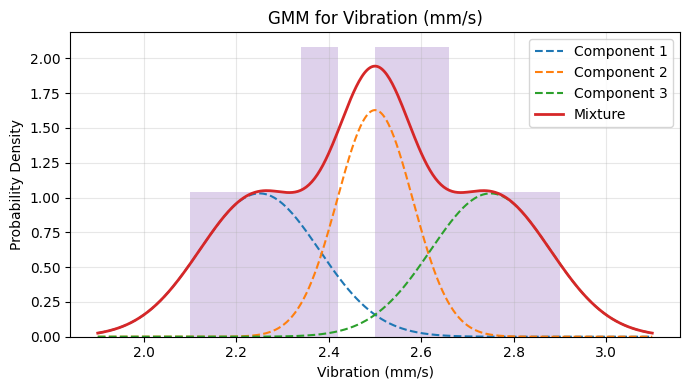

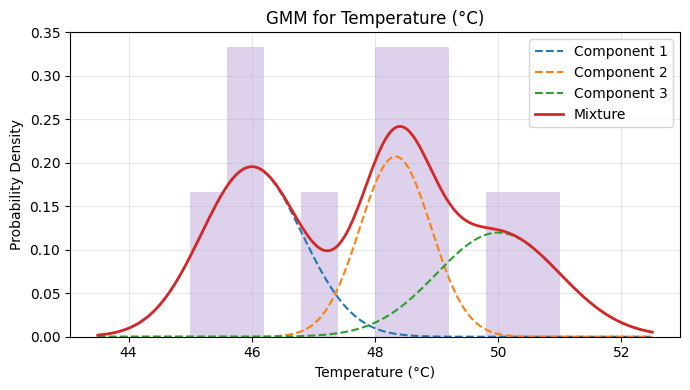

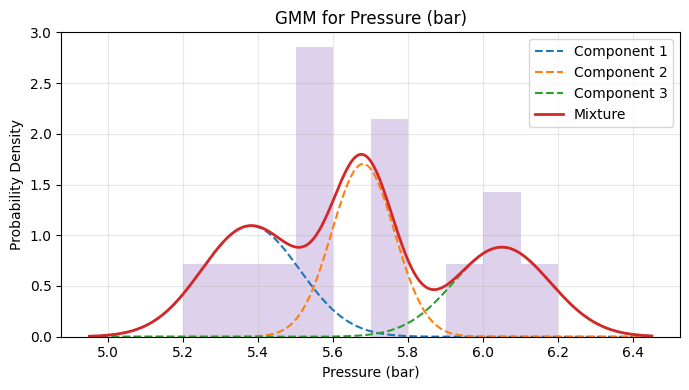

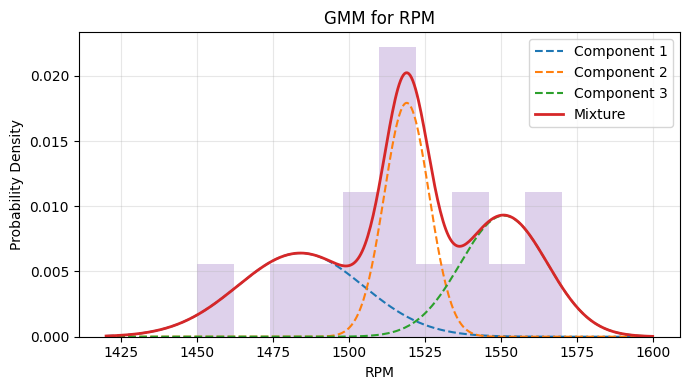

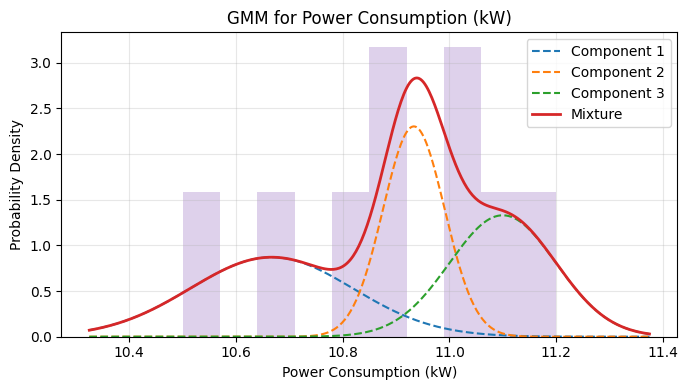

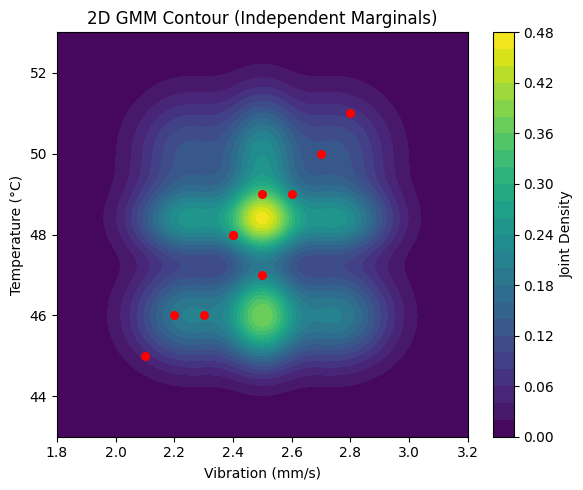

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# Gaussian PDF (1D)

def gaussian_1d(x, mu, var):
    return (1 / np.sqrt(2 * np.pi * var)) * np.exp(-(x - mu) ** 2 / (2 * var))



# Safe variance to avoid collapse

def safe_variance(x, min_frac=0.05):
    """
    x        : 1D data
    min_frac : minimum variance as fraction of data range
    """
    if len(x) <= 1:
        return 1.0

    data_var = np.var(x, ddof=1)
    data_range = np.max(x) - np.min(x)
    min_var = (min_frac * data_range) ** 2

    return max(data_var, min_var)



# Simple 1D GMM initialization

def gmm_1d(data, K=2):
    data = data[~np.isnan(data)]
    data = np.sort(data)

    splits = np.array_split(data, K)

    mus, vars_, pis = [], [], []
    N = len(data)

    for s in splits:
        mus.append(np.mean(s))
        vars_.append(safe_variance(s))
        pis.append(len(s) / N)

    return mus, vars_, pis



# Train GMM for each feature

def gmm_model(X, k=2):
    gmm_models = []
    for i in range(X.shape[0]):
        mus, vars_, pis = gmm_1d(X[i], k)
        gmm_models.append((mus, vars_, pis))
    return gmm_models



# GMM PDF

def gmm_1d_pdf(x, mus, vars_, pis):
    pdf = np.zeros_like(x, dtype=float)
    for mu, var, pi in zip(mus, vars_, pis):
        pdf += pi * gaussian_1d(x, mu, var)
    return pdf



# 🔹 MACHINE SENSOR DATA (CHANGED EXAMPLE)

X = np.array([
    # Vibration (mm/s)
    [2.1, 2.3, 2.5, 2.4, 2.2, 2.6, 2.7, 2.8, 2.5, 2.4, 2.6, 2.9,
     np.nan, np.nan, np.nan],

    # Temperature (°C)
    [45, 46, 47, 48, 46, 49, 50, 51, 49, 48,
     np.nan, np.nan, np.nan, np.nan, np.nan],

    # Pressure (bar)
    [5.2, 5.3, 5.5, 5.6, 5.4, 5.7, 5.8, 5.9,
     5.6, 5.5, 5.7, 6.0, 6.1, 6.2,
     np.nan],

    # RPM
    [1450, 1480, 1500, 1520, 1490, 1510, 1530,
     1540, 1550, 1520, 1500, 1515, 1535, 1560, 1570],

    # Power Consumption (kW)
    [10.5, 10.7, 10.9, 11.0, 10.8, 11.1, 11.2, 11.0, 10.9,
     np.nan, np.nan, np.nan, np.nan, np.nan, np.nan]
])

labels = [
    "Vibration (mm/s)",
    "Temperature (°C)",
    "Pressure (bar)",
    "RPM",
    "Power Consumption (kW)"
]

# -------------------------------
# Train GMMs
# -------------------------------
gmm_models = gmm_model(X, k=3)


# 1D GMM VISUALIZATION

for i, label in enumerate(labels):
    data = X[i][~np.isnan(X[i])]
    mus, vars_, pis = gmm_models[i]

    x_vals = np.linspace(
        data.min() - 0.25 * np.ptp(data),
        data.max() + 0.25 * np.ptp(data),
        400
    )

    plt.figure(figsize=(7, 4))
    mixture = np.zeros_like(x_vals)

    for k in range(len(mus)):
        comp = pis[k] * gaussian_1d(x_vals, mus[k], vars_[k])
        mixture += comp
        plt.plot(x_vals, comp, '--', label=f'Component {k + 1}')

    plt.plot(x_vals, mixture, linewidth=2, label='Mixture')
    plt.hist(data, bins=10, density=True, alpha=0.3)

    plt.title(f"GMM for {label}")
    plt.xlabel(label)
    plt.ylabel("Probability Density")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()



#  2D JOINT DENSITY (INDEPENDENT MARGINALS)

i, j = 0, 1   # Vibration vs Temperature

mus_x, vars_x, pis_x = gmm_models[i]
mus_y, vars_y, pis_y = gmm_models[j]

x = np.linspace(1.8, 3.2, 200)
y = np.linspace(43, 53, 200)

Xg, Yg = np.meshgrid(x, y)

Px = gmm_1d_pdf(x, mus_x, vars_x, pis_x)
Py = gmm_1d_pdf(y, mus_y, vars_y, pis_y)

Z = np.outer(Py, Px)

plt.figure(figsize=(6, 5))
plt.contourf(Xg, Yg, Z, levels=30, cmap="viridis")
plt.colorbar(label="Joint Density")

plt.scatter(
    X[i][~np.isnan(X[i])][:len(X[j][~np.isnan(X[j])])],
    X[j][~np.isnan(X[j])],
    c="red", s=30
)

plt.xlabel("Vibration (mm/s)")
plt.ylabel("Temperature (°C)")
plt.title("2D GMM Contour (Independent Marginals)")
plt.tight_layout()
plt.show()
